# Ejemplo Video games sales with ratings
Estos datos son una submuestra del conjunto de datos de Kaggle, `Video Game Sales with Ratings`. Este conjunto recopila información sobre videojuegos lanzados en distintos años y plataformas, junto con sus características y desempeño comercial.

Su objetivo principal es analizar las ventas mundiales de videojuegos, cómo varían según la plataforma, género, año, desarrolladora, y cómo las valoraciones de usuarios y críticos pueden influir en el éxito comercial. En concreto, se analizarán las ventas de los videojuegos publicados entre 2012 y 2015.

**Variables explicativas**:
- `Name`: Nombre del videojuego.
- `Platform`: Plataforma donde se lanzó el juego (por ejemplo, PS4, Xbox, Nintendo Switch, PC).
- `Year_of_Release`: Año en que se lanzó el videojuego.
- `Genre`: Género del videojuego (acción, aventura, deportes, rol, etc.).
- `Publisher`: Compañía que publicó el videojuego.
- `Developer`: Compañía que desarrolló el videojuego.
- `Rating`: Clasificación por edades según la ESRB (por ejemplo, E = para todos, M = para adultos).
- `NA_Sales`:  Ventas en Norteamérica (millones de unidades).
- `EU_Sales`: Ventas en Europa (millones de unidades).
- `JP_Sales`:Ventas en Japón (millones de unidades).
- `Other_Sales` :Ventas en otras regiones (millones de unidades).
- `Critic_Score`:Puntuación promedio otorgada por críticos profesionales (generalmente en una escala de 0 a 100). Representa la valoración experta del juego.
- `Critic_Count`: Número de críticos que han evaluado y puntuado el videojuego.
- `User_Score`: Puntuación promedio otorgada por usuarios o jugadores (normalmente en una escala de 0 a 10, a veces con decimales). Refleja la opinión de la comunidad.
- `User_Count`: Número total de usuarios que han dado una puntuación al juego.

**Variable objetivo**: 
- `Global_Sales`: Ventas totales globales (millones de unidades). Esta es la variable objetivo para regresión o binarización.

In [1]:
import pandas as pd
import numpy as np

# Cambia la ruta al archivo descargado en tu máquina
file_path = "C:\\Users\\user\\OneDrive - Universidad Complutense de Madrid (UCM)\\Documentos\\Titulo Propio\\Machine Learning\\Redes Neuronales\\Python\\Datasets\\Video_Games_Sales_2012-15.csv"  

df = pd.read_csv(file_path)

## Escoge tus variables de trabajo
La base de datos original incluye 15 variables explicativas. Para facilitarte la existencia, escoge las *6* que consideres que puedan resultar más útiles intuitivamente. 

La idea de esta simplificación es reducir la base de datos para facilitar su manipulación en ML. En condiciones "reales", habría que tomar decisiones razonadas con procesos estadísticos, en este caso, se toman decisiones aleatorias o intuitivas.

**IMPORTANTE** se desarrollarán tanto problemas de regresión (variable `Global_Sales`) como problemas de clasificación binaria. Para ello, binarizarás esta variable y crearás una nueva, `BIN_Global_Sales` que clasifique como 1 los videojuegos con altas ventas (valor superior a la mediana).

**PISTA**: para calcular la mediana, `mediana = df['Global_Sales'].median()`

Explica brevemente por qué has escogido estas variables: sólo quiero garantizar que lo has pensado durante dos minutos y no ha sido una decisión azarosa.

El resto de apartados los desarrollarás a partir de las variables aquí seleccionadas. Ten en cuenta que puede haber variables altamente correlacionadas, con muchos datos faltantes o poco útiles. Te ayudará a tomar la decisión graficar la relación entre la variable objetivo y las variables explicativas.

Pasos:
- Obtener la variable `BIN_Global_Sales`
- Análisis estructural de la base de datos: cabecera de los datos que selecciones, su tamaño, tipo de las variables
- Descriptivos
- Análisis de datos faltantes
- Establecer `Xp`, `y_bin`, `y_cont`
- Representación del comportamiento de la variable objetivo binaria, `BIN_Global_Sales`, respecto a las varibles explicativas

In [3]:
df.head()
df.shape
df.dtypes
df.describe
df.isna().sum()

Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       1304
Critic_Count       1304
User_Score         1115
User_Count         1115
Developer          1003
Rating             1053
dtype: int64

In [5]:
mediana = df['Global_Sales'].median()
df['BIN_Global_Sales'] = (df['Global_Sales'] > mediana).astype(int)

### Sobre NA
- Es fundamental diferenciar entre registros duplicados por error y observaciones legítimas que comparten exactamente los mismos valores. Por ejemplo, pueden existir dos coches distintos con idénticas características.
- Solo deben eliminarse duplicados si se tiene la certeza de que corresponden a un error de registro. Eliminar observaciones legítimas puede alterar de forma significativa el modelo.
- A modo de ejemplo: si en una regresión simple aparecen mil veces la observación (1,1) y dos veces la observación (0,1), la recta de regresión válida sería x = y. Si se eliminan esas repeticiones legítimas, el modelo resultante sería completamente diferente.

In [7]:
df=df.dropna()
X = df[['Platform', 'Year_of_Release','Genre','Publisher','NA_Sales','Rating']]
y_cont=df['Global_Sales']
y_bin=df['BIN_Global_Sales']
continuas=['Year_of_Release','NA_Sales']
categoricas=['Platform','Genre','Publisher','Rating']

**OJO** a las categorías poco representadas, pueden dar problemas en OHE
La siguiente celda es una opción, otra es agrupar categorías directamente en OHE

In [9]:
# Umbral mínimo de frecuencia (por ejemplo, 100 observaciones)
umbral = 50

# Columna categórica: 'Genre', por ejemplo
frecuencias_g = df['Genre'].value_counts()
frecuencias_pt = df['Platform'].value_counts()
frecuencias_p = df['Publisher'].value_counts()
frecuencias_r = df['Rating'].value_counts()
# Etiquetar las categorías raras como 'Other'
df['Genre'] = df['Genre'].apply(lambda x: x if frecuencias_g[x] >= umbral else 'Other')
# Etiquetar las categorías raras como 'Other'
df['Platform'] = df['Platform'].apply(lambda x: x if frecuencias_pt[x] >= umbral else 'Other')
df['Publisher'] = df['Publisher'].apply(lambda x: x if frecuencias_p[x] >= umbral else 'Other')
df['Rating'] = df['Rating'].apply(lambda x: x if frecuencias_r[x] >= umbral else 'Other')

for col in categoricas:
    print(col)
    print(df[col].value_counts())
    print()

Platform
Platform
PS3      211
X360     170
PS4      147
PC       137
XOne     104
PSV       96
3DS       90
WiiU      81
Other      7
Name: count, dtype: int64

Genre
Genre
Action          355
Role-Playing    139
Other           136
Shooter         133
Sports          113
Racing           64
Fighting         53
Misc             50
Name: count, dtype: int64

Publisher
Publisher
Other                                     517
Electronic Arts                           111
Ubisoft                                    92
Activision                                 69
Warner Bros. Interactive Entertainment     67
Nintendo                                   66
Namco Bandai Games                         63
Take-Two Interactive                       58
Name: count, dtype: int64

Rating
Rating
M       376
T       272
E       218
E10+    177
Name: count, dtype: int64



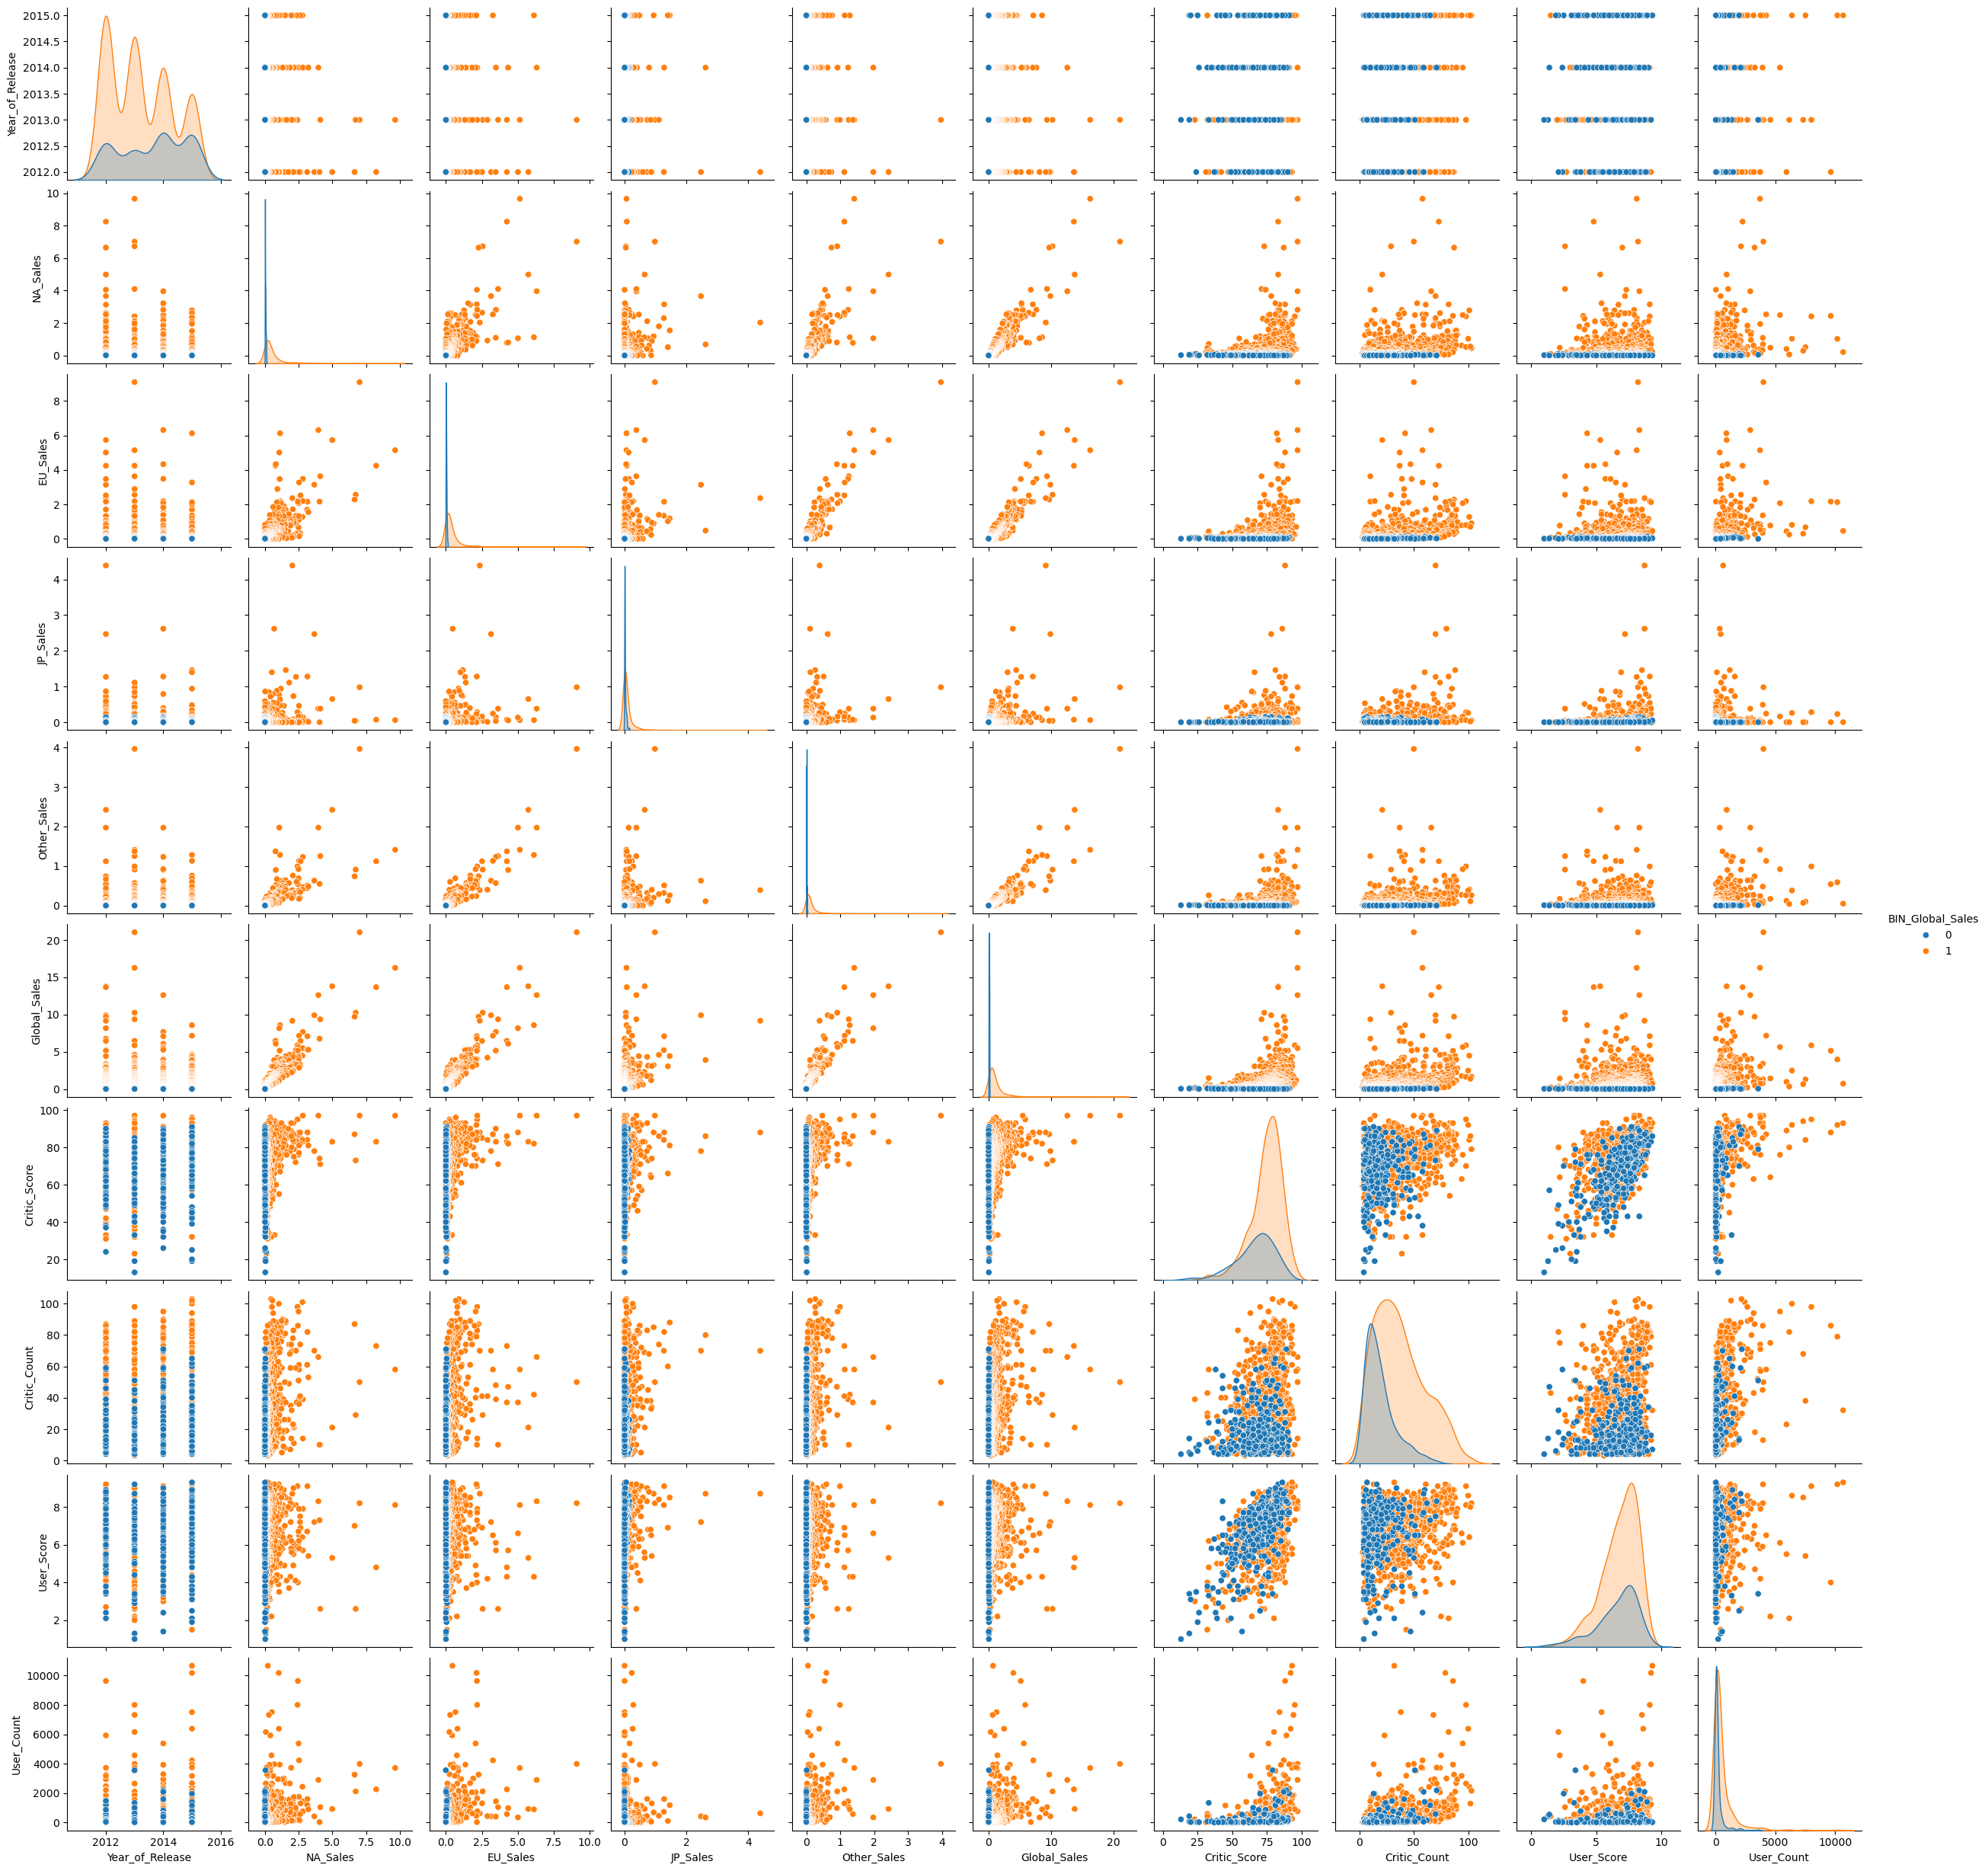

In [24]:
import seaborn as sns
sns.pairplot(df, hue='BIN_Global_Sales')

## 1. MLP y SelectKbest. Problema de regresión
Aplica un proceso de selección de variables `SelectKbest` para escoger 4 variables explicativas (ojo a las transformaciones previas que puedan ser necesarias).

A partir de las variables proporcionadas por el selector, realizar una búsqueda exhaustiva de hiperparámetros en base al criterio establecido. Justifica la rejilla propuesta.

Escoge 4 modelos candidatos, y en función del rendimiento, estabilidad y complejidad, escoge tu modelo ganador. Justifica el proceso.

In [11]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest
seed=123

X_train, X_test, y_train, y_test = train_test_split(X, y_cont, test_size=0.2, random_state=seed)

transformer = ColumnTransformer([('ohe', OneHotEncoder(drop='first',handle_unknown="infrequent_if_exist", min_frequency=5),categoricas),
                                 ('minmax',MinMaxScaler(),continuas)])

#transformer2 = ColumnTransformer([('ohe', OneHotEncoder(drop='first'),categoricas),   ('STD',StandardScaler(),continuas)])
X_train_tr = transformer.fit_transform(X_train)
X_test_tr = transformer.transform(X_test)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [13]:
selector = SelectKBest(k=4)
X_train_selected = selector.fit_transform(X_train_tr, y_train)
X_test_selected = selector.transform(X_test_tr)

### ¿Arquitectura razonable?
- `X`tiene 1043 observaciones
- `X_train_` tiene aproximadamente 834 observaciones
- Hemos establecido $k=4$ variables input con `SelectKBest`
- Aplicamos la fórmula del número total de parámetros en una red de una sola capa: $h*(k+1)+h+1$, y reservamos (aprox) 25 observaciones para cada parámetro: $$h*(4+1)+h+1=\frac{1043}{25} \longrightarrow 6h = \frac{1043}{25} \longrightarrow h =6.78$$
- Buscaremos la cantidad de nodos ocultos en un "entorno cercano a 6".

In [15]:
red = MLPRegressor(max_iter=500,random_state=1234)
#definimos los parámetros que queremos tunear
params = {
    'max_iter': [500],
    'hidden_layer_sizes': [5,7,9],
    'activation': ['tanh','relu'],
    'alpha': [0.001,0.0001]
}
scoring_metrics = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='r2')


grid.fit(X_train_selected, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer

GridSearchCV(cv=4, estimator=MLPRegressor(max_iter=500, random_state=1234),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.001, 0.0001],
                         'hidden_layer_sizes': [5, 7, 9], 'max_iter': [500]},
             refit='r2',
             scoring=['neg_mean_squared_error', 'neg_mean_absolute_error',
                      'r2'])

### NO HAY CONVERGENCIA
Habría que aumentar el número de iteraciones! de momento y como ejemplo tiramos con estos modelos

In [16]:
# Obtener resultados del grid search
results = pd.DataFrame(grid.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_r2', 'mean_test_neg_mean_squared_error']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

Resultados de Grid Search:
                                               params  mean_test_r2  \
0   {'activation': 'tanh', 'alpha': 0.001, 'hidden...      0.653457   
1   {'activation': 'tanh', 'alpha': 0.001, 'hidden...      0.708830   
2   {'activation': 'tanh', 'alpha': 0.001, 'hidden...      0.717341   
3   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...      0.653167   
4   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...      0.708757   
5   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...      0.717220   
6   {'activation': 'relu', 'alpha': 0.001, 'hidden...      0.487820   
7   {'activation': 'relu', 'alpha': 0.001, 'hidden...      0.782907   
8   {'activation': 'relu', 'alpha': 0.001, 'hidden...      0.676271   
9   {'activation': 'relu', 'alpha': 0.0001, 'hidde...      0.487859   
10  {'activation': 'relu', 'alpha': 0.0001, 'hidde...      0.782991   
11  {'activation': 'relu', 'alpha': 0.0001, 'hidde...      0.676428   

    mean_test_neg_mean_squared_error  
0         

### ¿Cómo analizar?
Por ejemplo, analizando r2 (porque hemos hecho el refit en función de esa métrica y por tanto es la más relevante). 

Para ello, ordenamos de mayor a menor y nos quedamos con los primeros.

In [308]:
results = results.sort_values(by="mean_test_r2", ascending=False)


In [310]:
# se seleccionan los modelos candidatos, y analiza su robustez a lo largo de cross validation.
#iloc accede a la fila de posición [i]
ac_0 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[0]
ac_1 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[1]
ac_2 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[2]
ac_3 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[3]

C:\Users\user\AppData\Local\Temp\ipykernel_27388\2173359645.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac_0.values,ac_1.values, ac_2.values, ac_3.values], labels = ['MLP0','MLP1','MLP2','MLP3'])


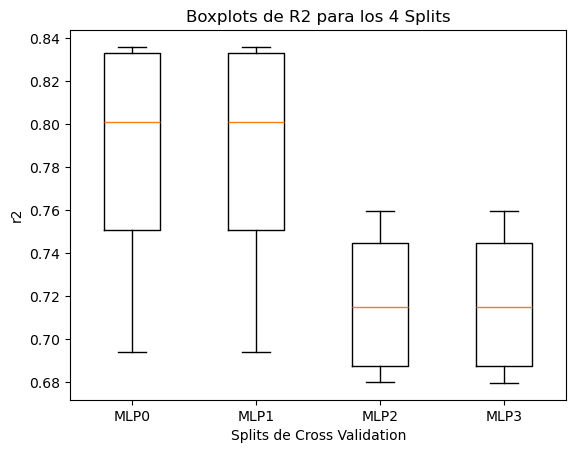

In [312]:
import matplotlib.pyplot as plt
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([ac_0.values,ac_1.values, ac_2.values, ac_3.values], labels = ['MLP0','MLP1','MLP2','MLP3'])
plt.title('Boxplots de R2 para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('r2')
plt.show()

In [314]:
results['params'].iloc[0]
# si queremos ver un parámetro concreto
#results['params'].iloc[0]['hidden_layer_sizes']

{'activation': 'relu',
 'alpha': 0.0001,
 'hidden_layer_sizes': 7,
 'max_iter': 500}

## Parece que el modelo MLP0 es uno de los candidatos, ¿sigo indagando?
- Vamos a entrenar el modelo MLP0 y otro similar con 6 neuronas en capa oculta, y otro con 8 (pues 7 estaba en el extremo inferior)
- Vamos a aumentar el número de iteraciones


In [317]:
## Vamos a entrenar el modelo MLP0 y otro similar con 6 neuronas en capa oculta
## Vamos a aumentar el número de iteraciones

red = MLPRegressor(max_iter=1000,random_state=1234)
#definimos los parámetros que queremos tunear
params = {
    'hidden_layer_sizes': [6,7,8],
    'activation': ['relu'],
    'alpha': [0.0001]
}
scoring_metrics = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='r2')


grid.fit(X_train_selected, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=4, estimator=MLPRegressor(max_iter=1000, random_state=1234),
             param_grid={'activation': ['relu'], 'alpha': [0.0001],
                         'hidden_layer_sizes': [6, 7, 8]},
             refit='r2',
             scoring=['neg_mean_squared_error', 'neg_mean_absolute_error',
                      'r2'])

In [261]:
# Obtener resultados del grid search
results = pd.DataFrame(grid.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_r2', 'mean_test_neg_mean_squared_error']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

Resultados de Grid Search:
                                              params  mean_test_r2  \
0  {'activation': 'relu', 'alpha': 0.0001, 'hidde...      0.824057   
1  {'activation': 'relu', 'alpha': 0.0001, 'hidde...      0.820247   
2  {'activation': 'relu', 'alpha': 0.0001, 'hidde...      0.823308   

   mean_test_neg_mean_squared_error  
0                         -0.417261  
1                         -0.423711  
2                         -0.418713  


In [263]:
# se seleccionan los modelos candidatos, y analiza su robustez a lo largo de cross validation.
#iloc accede a la fila de posición [i]
ac_0 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[0]
ac_1 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[1]
ac_2 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[2]

C:\Users\user\AppData\Local\Temp\ipykernel_27388\879300781.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac_0.values,ac_1.values,ac_2.values], labels = ['MLP0','MLP1','MLP2'])


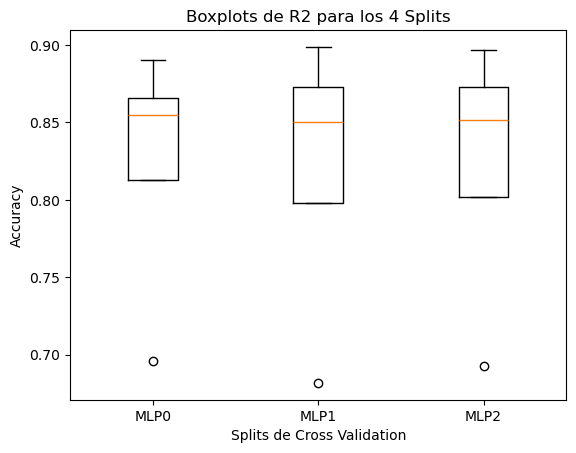

In [265]:
import matplotlib.pyplot as plt
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([ac_0.values,ac_1.values,ac_2.values], labels = ['MLP0','MLP1','MLP2'])
plt.title('Boxplots de R2 para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('R2')
plt.show()

## ¿Ganador?
- Son modelos muy similares en mediana, pero los más complejos, MLP1 (7 neuronas) y MLP2 (8 neuronas) tienen más variabilidad
- Nos quedamos con el de 6 neuronas en la capa oculta

No obstante, se podría seguir indagando:
- Cambiando alpha para el modelo de 6 neuronasl
- Analizando iteraciones
- Una CV más compleja para analizar más en detalle la estabilidad
-.....
- Decidir que no tengo más tiempo y la diferencia es demasiado sutil

# 2 MLP y RFE para clasificación
Aplica un proceso de selección de variables RFE para escoger 4 variables explicativas (ojo a las transformaciones previas que puedan ser necesarias).

A partir de las variables proporcionadas por el selector, realizar una búsqueda exhaustiva de hiperparámetros en base al criterio establecido. Justifica la rejilla propuesta.

Escoge 5 modelos candidatos, y en función del rendimiento, estabilidad y complejidad, escoge tu modelo ganador

Parte del trabajo previo de razonar la arquitectura lo podemos heredar del problema de regresión

In [270]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
seed=12345
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.24, random_state=seed)

transformer = ColumnTransformer([('ohe', OneHotEncoder(drop='first'),categoricas),
                                 ('minmax',MinMaxScaler(),continuas)])

transformer2 = ColumnTransformer([('ohe', OneHotEncoder(drop='first',handle_unknown="infrequent_if_exist", min_frequency=5),categoricas),
                                 ('minmax',StandardScaler(),continuas)])
X_train_tr = transformer2.fit_transform(X_train)
X_test_tr = transformer2.transform(X_test)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [272]:
selector = RFE(LogisticRegression(),n_features_to_select=5)
X_train_selected = selector.fit_transform(X_train_tr, y_train)
X_test_selected = selector.transform(X_test_tr)

In [274]:
red = MLPClassifier(random_state=1234)
#definimos los parámetros que queremos tunear
#suponiendo que reservamos unas 20 observaciones por parámetro, deberíamos probar con no más de 15 nodos en la capa oculta
#por el principio de parsimonia, ante igualdad de resultados, mejor modelos sencillos
params = {
    'max_iter': [600], #cantidad de iteraciones que se le permiten al algoritmo de optimizacion
    'hidden_layer_sizes': [4,5,6,7,8],#redes con una sola capa oculta, con un tamaño distinto en cada arquitectura
    'activation': ['tanh','relu'], #función de activación usada
    'alpha': [0.001,0.0001] #regularización L2, valor alto puede resultar en un modelo más sesgado pero con menor varianza. 
    #valor más bajo permite que el modelo se ajuste más a los datos de tr, aunque con un mayor riesgo de sobreajuste
}

scoring_metrics = ['accuracy', 'f1_macro']
grid = GridSearchCV(red, param_grid=params,cv=4, scoring = scoring_metrics, refit='accuracy')

grid.fit(X_train_selected, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer

GridSearchCV(cv=4, estimator=MLPClassifier(random_state=1234),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.001, 0.0001],
                         'hidden_layer_sizes': [4, 5, 6, 7, 8],
                         'max_iter': [600]},
             refit='accuracy', scoring=['accuracy', 'f1_macro'])

In [278]:
# Obtener resultados del grid search
results = pd.DataFrame(grid.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_accuracy']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos
results = results.sort_values(by="mean_test_accuracy", ascending=False)

Resultados de Grid Search:
                                               params  mean_test_accuracy
0   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.893939
1   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.893939
2   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.897727
3   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.893939
4   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.893939
5   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.893939
6   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.893939
7   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.897727
8   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.893939
9   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.893939
10  {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.896465
11  {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.893939
12  {'activ

In [284]:
# se seleccionan los modelos candidatos, y analiza su robustez a lo largo de cross validation.
#iloc accede a la fila de posición [i]
ac_0 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[0]
ac_1 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[1]
ac_2 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[2]

C:\Users\user\AppData\Local\Temp\ipykernel_27388\3286866865.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac_0.values,ac_1.values,ac_2.values], labels = ['MLP0','MLP1','MLP2'])


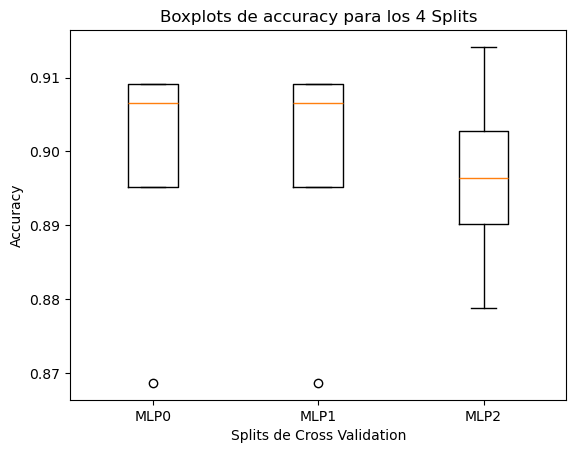

In [286]:
import matplotlib.pyplot as plt
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([ac_0.values,ac_1.values,ac_2.values], labels = ['MLP0','MLP1','MLP2'])
plt.title('Boxplots de accuracy para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('Accuracy')
plt.show()

MLP0 y MLP1 son muy similares, comparamos complejidad

In [295]:
print(f"MLP0 {results['params'].iloc[0]}")
print(f"MLP1 {results['params'].iloc[1]}")

MLP0 {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': 6, 'max_iter': 600}
MLP1 {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': 6, 'max_iter': 600}


Desde el punto de vista de complejidad del modelo, el más sencillo sería el que esté más regularizado, porque:
- penaliza más los pesos grandes
- reduce la capacidad del modelo
- tiende a generar funciones más suaves


Porque una alpha mayor = más regularización, por tanto menos complejidad efectiva.

Como MLP0 está en el extremo de la parrilla, no hace falta seguir buscando.

## Paso final, si me quedo con MLP 0, replico el proceso y lo entreno para su puesta en producción

In [53]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
seed=12345
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.24, random_state=seed)

transformer = ColumnTransformer([('ohe', OneHotEncoder(drop='first'),categoricas),
                                 ('minmax',MinMaxScaler(),continuas)])

transformer2 = ColumnTransformer([('ohe', OneHotEncoder(drop='first',handle_unknown="infrequent_if_exist", min_frequency=5),categoricas),
                                 ('minmax',StandardScaler(),continuas)])
X_train_tr = transformer2.fit_transform(X_train)
X_test_tr = transformer2.transform(X_test)


selector = RFE(LogisticRegression(),n_features_to_select=5)
X_train_selected = selector.fit_transform(X_train_tr, y_train)
X_test_selected = selector.transform(X_test_tr)


candidata = MLPClassifier(**results.iloc[0].params,random_state=1234)
candidata.fit(X_train_selected, y_train)
#También podríamos haber binarizado y_pred proba con el umbral que mejor nos venga

## Calculo predicciones en test, y siempre termino con matriz de confusión
y_pred = candidata.predict(X_test_selected)


C:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [54]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test, y_pred)
cm

array([[ 49,  14],
       [ 15, 173]], dtype=int64)